# Solving the 1D Wave Equation for a Vibrating String

**Course:** Partial Differential Equations with Applications in Physics and Industry  
**Team:** Michał Raczkiewicz, Michał Strugacz, Samanta Szenajch  
**Prepared section focus:** numerical validation, convergence, stability, and plucked string simulation

This notebook solves the one-dimensional wave equation for a string fixed at both ends. It combines the mathematical model, the finite difference method, implementation, verification against an analytical solution, convergence analysis, stability analysis, and a physical simulation of a plucked string.


## 1. Introduction

A vibrating string, such as a guitar string, can be modeled as a one-dimensional elastic medium. After the string is displaced from equilibrium and released, waves travel along the string, reflect from the fixed endpoints, and interact to form standing wave patterns.

The goal of this project is to:

1. formulate the mathematical model,
2. implement a finite difference solver,
3. validate the numerical solution using an analytical solution,
4. investigate convergence and stability,
5. simulate a plucked string and interpret the results physically.


## 2. Mathematical Model

We consider the one-dimensional wave equation

\[
\frac{\partial^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2}, \qquad 0 < x < L, \quad t > 0,
\]

with fixed-end boundary conditions

\[
u(0,t)=0, \qquad u(L,t)=0,
\]

and initial conditions

\[
u(x,0)=g(x), \qquad u_t(x,0)=h(x).
\]

Here:

- \(u(x,t)\) is the transverse displacement of the string,
- \(L\) is the length of the string,
- \(c\) is the wave propagation speed,
- \(g(x)\) is the initial shape of the string,
- \(h(x)\) is the initial velocity.

For most numerical experiments we use the scaled values

\[
L=1, \qquad c=1.
\]


## 3. Physical Derivation

For a string under tension \(T\) with linear density \(\rho\), small transverse displacements lead to the equation

\[
\rho u_{tt} = T u_{xx}.
\]

After dividing by \(\rho\), we obtain

\[
u_{tt}=\frac{T}{\rho}u_{xx}.
\]

The wave speed is therefore

\[
c=\sqrt{\frac{T}{\rho}},
\]

so the final model is

\[
u_{tt}=c^2u_{xx}.
\]

A larger value of \(c\) means that disturbances travel faster along the string.


## 4. Analytical Solution for Validation

To validate the numerical method, we use the exact solution

\[
u_{\text{exact}}(x,t)=\sin(\pi x)\cos(\pi t).
\]

This solution satisfies the wave equation for \(L=1\) and \(c=1\), with

\[
g(x)=\sin(\pi x), \qquad h(x)=0.
\]

It also satisfies the fixed-end boundary conditions, because

\[
u(0,t)=0, \qquad u(1,t)=0.
\]


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots readable in the notebook.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


def exact_solution(x, t):
    """Analytical solution used for validation."""
    return np.sin(np.pi * x) * np.cos(np.pi * t)


def initial_displacement_test(x):
    """Initial displacement for the analytical test problem."""
    return np.sin(np.pi * x)


def initial_velocity_zero(x):
    """Zero initial velocity."""
    return np.zeros_like(x)


## 5. Finite Difference Method

We discretize the spatial and temporal domains as

\[
x_i=i\Delta x, \qquad t_n=n\Delta t.
\]

The second derivatives are approximated using central finite differences:

\[
u_{tt}(x_i,t_n) \approx \frac{u_i^{n+1}-2u_i^n+u_i^{n-1}}{\Delta t^2},
\]

\[
u_{xx}(x_i,t_n) \approx \frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta x^2}.
\]

Substitution into the wave equation gives

\[
\frac{u_i^{n+1}-2u_i^n+u_i^{n-1}}{\Delta t^2}
= c^2 \frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta x^2}.
\]

Solving for \(u_i^{n+1}\), we obtain the explicit scheme

\[
u_i^{n+1}=2u_i^n-u_i^{n-1}+r^2\left(u_{i+1}^n-2u_i^n+u_{i-1}^n\right),
\]

where

\[
r=\frac{c\Delta t}{\Delta x}
\]

is the Courant number.

Because the scheme uses two previous time levels, the first time step is computed separately:

\[
u_i^1=u_i^0+\Delta t h_i+\frac{1}{2}r^2\left(u_{i+1}^0-2u_i^0+u_{i-1}^0\right).
\]


In [2]:
def solve_wave_fdm(phi, psi, L=1.0, c=1.0, T=2.0, N=200, cfl=0.9):
    """
    Explicit finite-difference solver for the 1D wave equation:

        u_tt = c^2 u_xx,       0 < x < L, t > 0
        u(0,t) = u(L,t) = 0
        u(x,0) = Phi(x)
        u_t(x,0) = Psi(x)

    Scheme:
        U_i^{n+1} = 2U_i^n - U_i^{n-1}
                    + r^2 (U_{i+1}^n - 2U_i^n + U_{i-1}^n)

    where:
        r = c * dt / dx

    Parameters
    ----------
    phi : callable
        Initial displacement Phi(x).
    psi : callable
        Initial velocity Psi(x).
    L : float
        Length of the string.
    c : float
        Wave speed.
    T : float
        Final simulation time.
    N : int
        Number of spatial intervals. Number of grid points is N+1.
    cfl : float
        Requested CFL number. Stable explicit scheme requires cfl <= 1.

    Returns
    -------
    x : ndarray
        Spatial grid, shape (N+1,).
    t : ndarray
        Time grid, shape (Nt+1,).
    U : ndarray
        Numerical solution, shape (Nt+1, N+1).
        U[n, i] approximates u(x_i, t_n).
    dx, dt, r : floats
        Spatial step, time step, actual CFL number.
    """
    if N < 2:
        raise ValueError("N must be at least 2.")
    if L <= 0 or c <= 0 or T <= 0:
        raise ValueError("L, c and T must be positive.")
    if cfl <= 0:
        raise ValueError("cfl must be positive.")

    dx = L / N

    # Choose dt from CFL and adjust it so that the last time is exactly T.
    dt_raw = cfl * dx / c
    Nt = int(np.ceil(T / dt_raw))
    dt = T / Nt
    r = c * dt / dx

    if r > 1.0:
        print(f"Warning: CFL = {r:.4f} > 1. The explicit scheme is expected to be unstable.")

    x = np.linspace(0.0, L, N + 1)
    t = np.linspace(0.0, T, Nt + 1)

    U = np.zeros((Nt + 1, N + 1), dtype=float)

    phi_values = np.asarray(phi(x), dtype=float)
    psi_values = np.asarray(psi(x), dtype=float)

    if phi_values.shape != x.shape:
        raise ValueError("phi(x) must return an array with the same shape as x.")
    if psi_values.shape != x.shape:
        raise ValueError("psi(x) must return an array with the same shape as x.")

    # Initial condition: U_i^0 = Phi(x_i)
    U[0, :] = phi_values
    U[0, 0] = 0.0
    U[0, -1] = 0.0

    # First time step obtained from Taylor expansion:
    # U_i^1 = Phi_i + dt Psi_i + 0.5 r^2 (Phi_{i+1} - 2Phi_i + Phi_{i-1})
    U[1, 1:-1] = (
        U[0, 1:-1]
        + dt * psi_values[1:-1]
        + 0.5 * r**2 * (U[0, 2:] - 2.0 * U[0, 1:-1] + U[0, :-2])
    )
    U[1, 0] = 0.0
    U[1, -1] = 0.0

    # Main time loop
    for n in range(1, Nt):
        U[n + 1, 1:-1] = (
            2.0 * U[n, 1:-1]
            - U[n - 1, 1:-1]
            + r**2 * (U[n, 2:] - 2.0 * U[n, 1:-1] + U[n, :-2])
        )

        # Boundary conditions: fixed ends
        U[n + 1, 0] = 0.0
        U[n + 1, -1] = 0.0

    return x, t, U, dx, dt, r

def solve_wave_1d(L, c, Nx, T, r, g, h):
    """
    Compatibility wrapper for the numerical experiments in this notebook.

    It converts the interface used in the experiments

        solve_wave_1d(L, c, Nx, T, r, g, h)

    to the interface of the FDM solver

        solve_wave_fdm(phi, psi, L, c, T, N, cfl).

    Returns only x, t and U, which is the format expected by the
    validation, convergence, stability and plucked string sections.
    """
    x, t, U, dx, dt, r_actual = solve_wave_fdm(
        phi=g,
        psi=h,
        L=L,
        c=c,
        T=T,
        N=Nx,
        cfl=r,
    )
    return x, t, U


def courant_number(x, t, c):
    """Compute the effective Courant number from grids x and t."""
    dx = x[1] - x[0]
    dt = t[1] - t[0]
    return c * dt / dx



## 6. Validation with Exact Solution

The first numerical experiment compares the finite difference solution with the exact solution. This is a basic check that the solver behaves correctly before it is used for more complicated simulations.


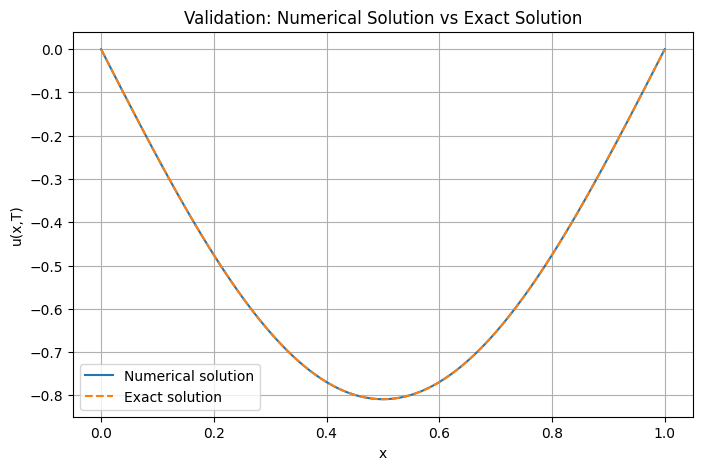

Final time: T = 0.800000
Effective Courant number: r = 0.800000
Maximum error at final time: 2.187188e-05


In [3]:
L = 1.0
c = 1.0
Nx = 100
T = 0.8
r = 0.8

x, t, U = solve_wave_1d(
    L=L,
    c=c,
    Nx=Nx,
    T=T,
    r=r,
    g=initial_displacement_test,
    h=initial_velocity_zero,
)

u_num = U[-1, :]
u_ex = exact_solution(x, t[-1])
max_error = np.max(np.abs(u_num - u_ex))

plt.plot(x, u_num, label="Numerical solution")
plt.plot(x, u_ex, "--", label="Exact solution")
plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Validation: Numerical Solution vs Exact Solution")
plt.legend()
plt.show()

print(f"Final time: T = {t[-1]:.6f}")
print(f"Effective Courant number: r = {courant_number(x, t, c):.6f}")
print(f"Maximum error at final time: {max_error:.6e}")


The numerical and analytical solutions are plotted at the final time. The maximum error is used as a quantitative measure of the accuracy of the method.


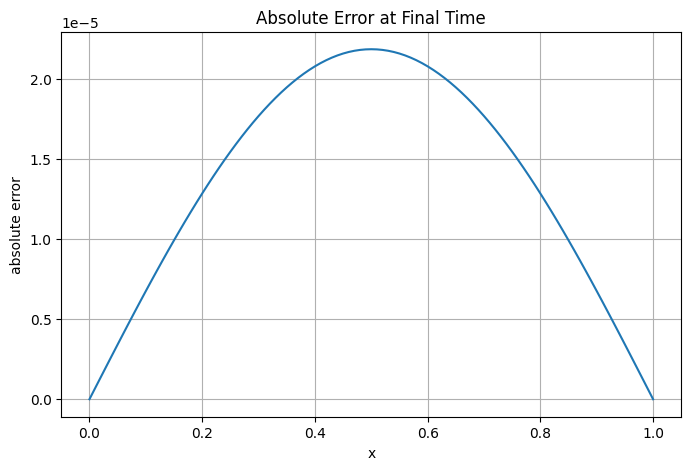

In [4]:
abs_error = np.abs(u_num - u_ex)

plt.plot(x, abs_error)
plt.xlabel("x")
plt.ylabel("absolute error")
plt.title("Absolute Error at Final Time")
plt.show()


## 7. Consistency Analysis

Using Taylor expansions around \((x_i,t_n)\), the central difference approximations satisfy

\[
\frac{u_i^{n+1}-2u_i^n+u_i^{n-1}}{\Delta t^2}
= u_{tt}(x_i,t_n)+O(\Delta t^2),
\]

and

\[
\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta x^2}
= u_{xx}(x_i,t_n)+O(\Delta x^2).
\]

Therefore, the local truncation error is

\[
O(\Delta t^2 + \Delta x^2).
\]

This means that the finite difference scheme is second-order accurate in both time and space, provided that the solution is sufficiently smooth.


## 8. Convergence Experiment

To test convergence, the analytical solution is computed on several grids. For each value of \(N_x\), the maximum error at the final time is calculated:

\[
E_{\max}=\max_i |u_i^N-u_{\text{exact}}(x_i,T)|.
\]

A log-log plot of the error against \(\Delta x\) is then used to estimate the convergence order. Since the method is second-order accurate, the expected slope is approximately 2.

In the experiment below we use \(T=0.8\). This keeps the Courant number equal to \(r=0.8\) for all tested grids and avoids measuring the error at a special time where the sine test mode may show artificial superconvergence.

In [5]:
def run_convergence_experiment(Nx_values, L=1.0, c=1.0, r=0.8, T=0.8):
    """Run the convergence experiment for several spatial grids."""
    rows = []

    for Nx in Nx_values:
        x, t, U = solve_wave_1d(
            L=L,
            c=c,
            Nx=Nx,
            T=T,
            r=r,
            g=initial_displacement_test,
            h=initial_velocity_zero,
        )

        u_num = U[-1, :]
        u_ex = exact_solution(x, t[-1])

        dx = L / Nx
        dt = t[1] - t[0]
        r_eff = c * dt / dx
        max_error = np.max(np.abs(u_num - u_ex))

        rows.append(
            {
                "Nx": Nx,
                "Delta x": dx,
                "Delta t": dt,
                "effective r": r_eff,
                "max error": max_error,
            }
        )

    return pd.DataFrame(rows)


Nx_values = [25, 50, 100, 200]
convergence_table = run_convergence_experiment(Nx_values)
convergence_table


,Nx,Delta x,Delta t,effective r,max error
0,25,0.040,0.032,0.8,0.000350
1,50,0.020,0.016,0.8,0.000088
2,100,0.010,0.008,0.8,0.000022
3,200,0.005,0.004,0.8,0.000005


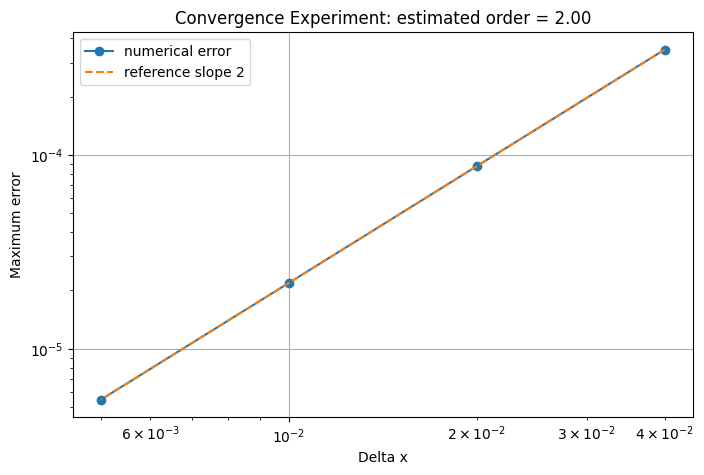

Estimated convergence order: 1.9998


In [6]:
# Estimate convergence order from the slope in the log-log plot.
log_dx = np.log(convergence_table["Delta x"])
log_error = np.log(convergence_table["max error"])
estimated_order = np.polyfit(log_dx, log_error, 1)[0]

plt.loglog(
    convergence_table["Delta x"],
    convergence_table["max error"],
    "o-",
    label="numerical error",
)

# Reference second-order line for visual comparison.
C_ref = convergence_table["max error"].iloc[0] / convergence_table["Delta x"].iloc[0] ** 2
plt.loglog(
    convergence_table["Delta x"],
    C_ref * convergence_table["Delta x"] ** 2,
    "--",
    label="reference slope 2",
)

plt.xlabel("Delta x")
plt.ylabel("Maximum error")
plt.title(f"Convergence Experiment: estimated order = {estimated_order:.2f}")
plt.legend()
plt.show()

print(f"Estimated convergence order: {estimated_order:.4f}")


The estimated convergence order is close to 2, which agrees with the second-order consistency analysis. Small deviations are normal because the error depends on the finite grid resolution and the selected time step.

## 9. Stability Experiment

For the explicit central finite difference scheme, the Courant stability condition is

\[
r=\frac{c\Delta t}{\Delta x}\leq 1.
\]

We compare three cases:

- \(r=0.8\): stable case,
- \(r=1.0\): limiting stable case,
- \(r=1.1\): unstable case.

To make the instability easier to observe, the stability test uses a triangular plucked-string initial condition, which contains a wider range of spatial frequencies than a single sine wave.


In [7]:
def plucked_string_shape(x, L=1.0, A=1.0, a=0.3):
    """
    Triangular initial displacement for a plucked string.

    The point a is the plucking point and A is the maximum amplitude.
    """
    x = np.asarray(x)
    return np.where(
        x <= a,
        A * x / a,
        A * (L - x) / (L - a),
    )


def g_plucked(x):
    return plucked_string_shape(x, L=1.0, A=1.0, a=0.3)


In [8]:
def run_stability_experiment(r_values, L=1.0, c=1.0, Nx=100, T=3.0):
    """Run simulations for different Courant numbers."""
    solutions = {}

    for r_value in r_values:
        x, t, U = solve_wave_1d(
            L=L,
            c=c,
            Nx=Nx,
            T=T,
            r=r_value,
            g=g_plucked,
            h=initial_velocity_zero,
        )
        solutions[r_value] = (x, t, U)

    return solutions


r_values = [0.8, 1.0, 1.1]
stability_solutions = run_stability_experiment(r_values)


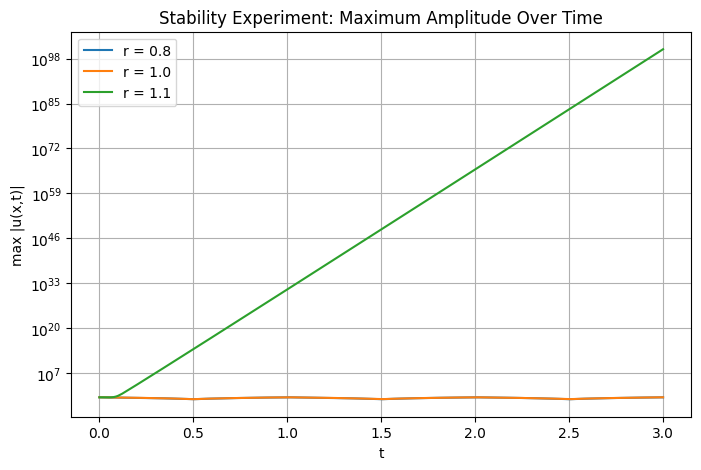

In [9]:
# Plot the maximum amplitude over time.
plt.figure(figsize=(8, 5))

for r_value, (x_stab, t_stab, U_stab) in stability_solutions.items():
    max_amplitude = np.max(np.abs(U_stab), axis=1)
    plt.semilogy(t_stab, max_amplitude, label=f"r = {r_value}")

plt.xlabel("t")
plt.ylabel("max |u(x,t)|")
plt.title("Stability Experiment: Maximum Amplitude Over Time")
plt.legend()
plt.show()


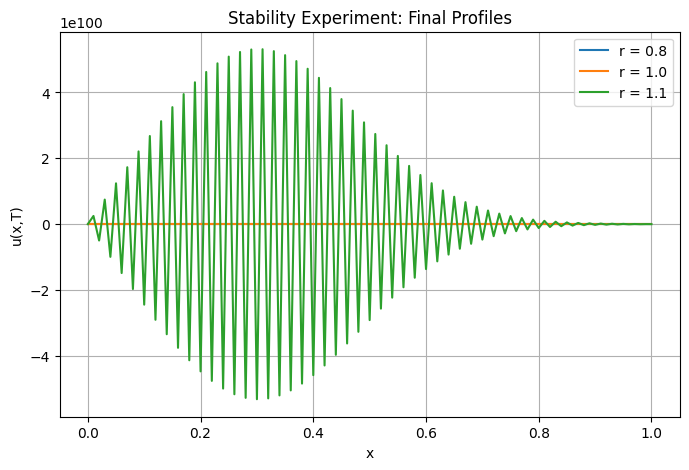

In [10]:
# Plot the final profiles.
plt.figure(figsize=(8, 5))

for r_value, (x_stab, t_stab, U_stab) in stability_solutions.items():
    plt.plot(x_stab, U_stab[-1, :], label=f"r = {r_value}")

plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Stability Experiment: Final Profiles")
plt.legend()
plt.show()


For \(r\leq 1\), the numerical solution remains bounded. For \(r>1\), the solution may grow rapidly and lose physical meaning. This confirms the importance of the Courant stability condition for the explicit finite difference method.


## 10. Plucked String Simulation

The main physical simulation uses a triangular initial displacement:

\[
g(x)=
\begin{cases}
\frac{A}{a}x, & 0\leq x\leq a,\\
\frac{A(L-x)}{L-a}, & a < x\leq L,
\end{cases}
\]

with zero initial velocity:

\[
h(x)=0.
\]

This is a simple model of a string plucked at the point \(x=a\).


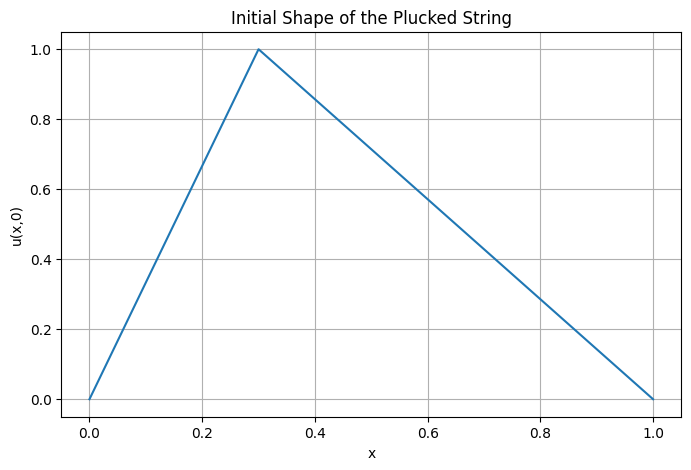

In [11]:
L = 1.0
c = 1.0
Nx = 300
T = 2.0
r = 0.8
A = 1.0
a = 0.3


def g_plucked_main(x):
    return plucked_string_shape(x, L=L, A=A, a=a)


x, t, U = solve_wave_1d(
    L=L,
    c=c,
    Nx=Nx,
    T=T,
    r=r,
    g=g_plucked_main,
    h=initial_velocity_zero,
)

plt.plot(x, U[0, :])
plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Shape of the Plucked String")
plt.show()


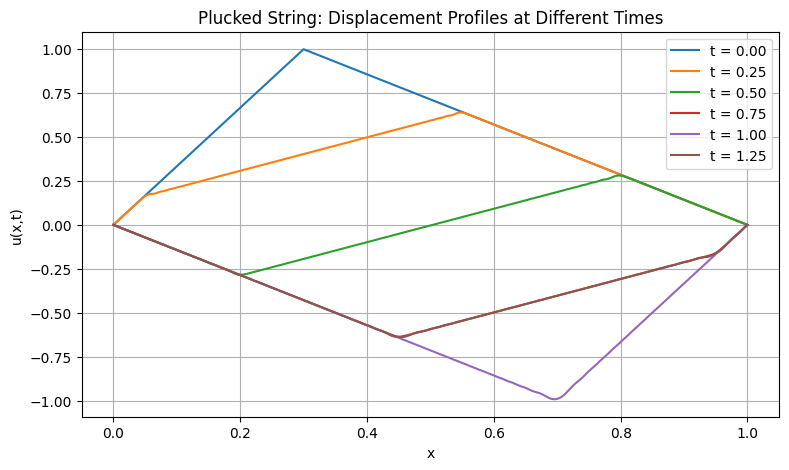

In [12]:
# Plot several time snapshots.
snapshot_times = [0.0, 0.25, 0.50, 0.75, 1.00, 1.25]

plt.figure(figsize=(9, 5))
for time_value in snapshot_times:
    n = np.argmin(np.abs(t - time_value))
    plt.plot(x, U[n, :], label=f"t = {t[n]:.2f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Plucked String: Displacement Profiles at Different Times")
plt.legend()
plt.show()


The triangular initial shape splits into two waves traveling in opposite directions. When these waves reach the fixed endpoints, they reflect with a change of sign. The repeated reflections create oscillatory patterns similar to the vibration of a guitar string.


## 11. Influence of the Plucking Point

The plucking point changes the initial shape of the string and therefore changes the relative contribution of different vibration modes. We compare three plucking points:

\[
a=0.25L, \qquad a=0.50L, \qquad a=0.75L.
\]


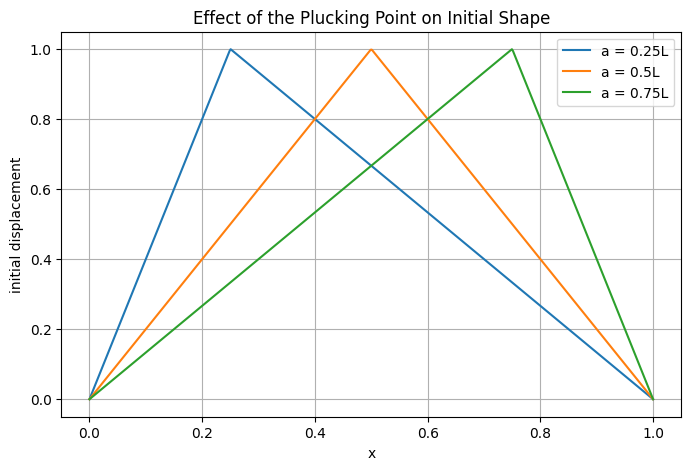

In [13]:
plucking_points = [0.25, 0.50, 0.75]
x_plot = np.linspace(0, L, 500)

plt.figure(figsize=(8, 5))
for a_value in plucking_points:
    plt.plot(
        x_plot,
        plucked_string_shape(x_plot, L=L, A=A, a=a_value),
        label=f"a = {a_value}L",
    )

plt.xlabel("x")
plt.ylabel("initial displacement")
plt.title("Effect of the Plucking Point on Initial Shape")
plt.legend()
plt.show()


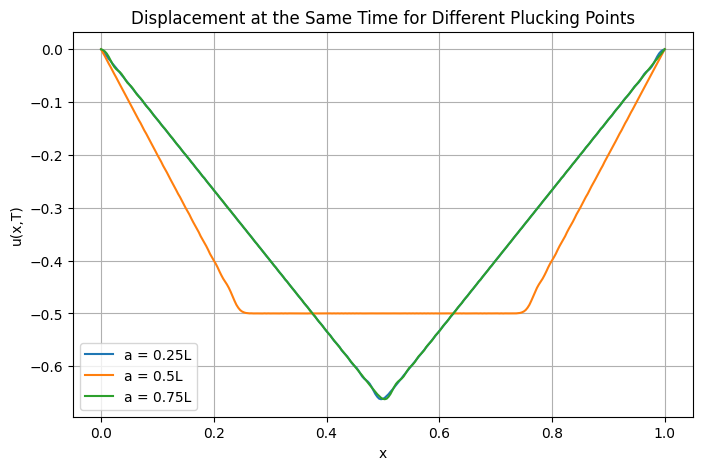

In [14]:
# Compare the solution at the same final time for different plucking points.
plt.figure(figsize=(8, 5))

for a_value in plucking_points:
    def g_temp(x, a_value=a_value):
        return plucked_string_shape(x, L=L, A=A, a=a_value)

    x_temp, t_temp, U_temp = solve_wave_1d(
        L=L,
        c=c,
        Nx=300,
        T=0.75,
        r=0.8,
        g=g_temp,
        h=initial_velocity_zero,
    )

    plt.plot(x_temp, U_temp[-1, :], label=f"a = {a_value}L")

plt.xlabel("x")
plt.ylabel("u(x,T)")
plt.title("Displacement at the Same Time for Different Plucking Points")
plt.legend()
plt.show()


Plucking the string in the middle creates a symmetric initial shape. Plucking closer to one end creates an asymmetric shape and excites different combinations of standing wave modes.


## 12. Optional: Numerical Energy

For the ideal wave equation without damping, the physical energy should remain approximately constant. A discrete approximation of the energy is

\[
E(t) \approx \frac{1}{2}\int_0^L u_t^2\,dx + \frac{c^2}{2}\int_0^L u_x^2\,dx.
\]

In the numerical method, small oscillations in the computed energy may appear because of discretization error.


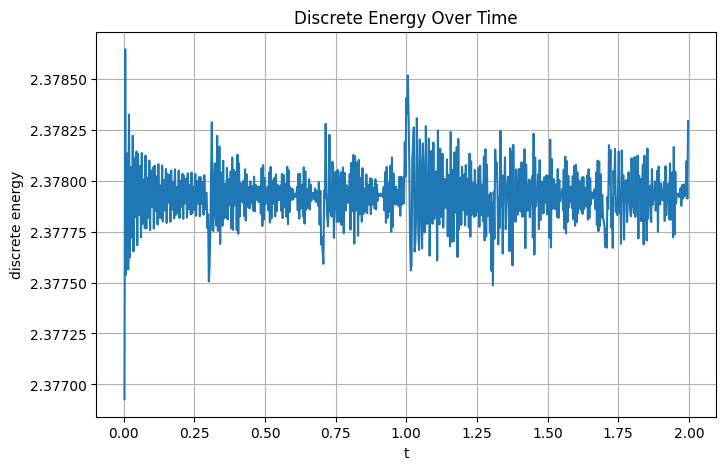

In [15]:
def compute_discrete_energy(U, x, t, c):
    """Approximate the energy of the numerical solution over time."""
    dx = x[1] - x[0]
    dt = t[1] - t[0]

    energies = []
    time_values = []

    for n in range(1, len(t) - 1):
        u_t = (U[n + 1, :] - U[n - 1, :]) / (2 * dt)
        u_x = np.diff(U[n, :]) / dx

        kinetic = 0.5 * dx * np.sum(u_t**2)
        potential = 0.5 * c**2 * dx * np.sum(u_x**2)

        energies.append(kinetic + potential)
        time_values.append(t[n])

    return np.array(time_values), np.array(energies)


energy_t, energy_values = compute_discrete_energy(U, x, t, c)

plt.plot(energy_t, energy_values)
plt.xlabel("t")
plt.ylabel("discrete energy")
plt.title("Discrete Energy Over Time")
plt.show()


## 13. Optional Animation

The following cell can be used to generate an animation inside Jupyter. It is disabled by default to keep the notebook lightweight. To use it, set `CREATE_ANIMATION = True` and run the cell.


In [16]:
CREATE_ANIMATION = False

if CREATE_ANIMATION:
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    fig, ax = plt.subplots(figsize=(8, 4))
    line, = ax.plot(x, U[0, :])
    ax.set_xlim(0, L)
    ax.set_ylim(1.2 * np.min(U), 1.2 * np.max(U))
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.set_title("Plucked String Animation")

    step = max(1, len(t) // 100)

    def update(frame):
        n = frame * step
        line.set_ydata(U[n, :])
        ax.set_title(f"Plucked String Animation, t = {t[n]:.3f}")
        return line,

    frames = len(t) // step
    anim = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
    display(HTML(anim.to_jshtml()))
    plt.close(fig)


## 14. Conclusions

The finite difference method was successfully applied to the one-dimensional wave equation for a string fixed at both endpoints.

The validation experiment showed good agreement between the numerical and exact solutions. The convergence experiment confirmed that the method is approximately second-order accurate, which agrees with the consistency analysis. The stability experiment demonstrated that the Courant number is crucial: the scheme remains stable for \(r\leq 1\), while for \(r>1\) the numerical solution becomes unstable.

The plucked string simulation showed how an initially triangular displacement evolves into traveling waves, which reflect from the fixed endpoints and form oscillatory patterns. The position of the plucking point affects the shape of the motion and the mixture of vibration modes.


## 15. Bibliography

1. R. J. LeVeque, *Finite Difference Methods for Ordinary and Partial Differential Equations*. SIAM, 2007.
2. H. P. Langtangen, *Finite Difference Methods for Wave Motion*, 2016.
3. W. A. Strauss, *Partial Differential Equations: An Introduction*. Wiley, 2007.
4. G. W. Griffiths and W. E. Schiesser, *Traveling Wave Analysis of Partial Differential Equations*. Academic Press, 2011.


## 16. How to Run This Notebook

Required Python packages:

```text
numpy
pandas
matplotlib
jupyter
```

Run all cells from top to bottom. The optional animation cell is disabled by default.
